# Tutorial - Module 2: Accessibility Analysis

This notebook is a template workflow to collect data and prepare the main data to perform a baseline physical accessibility analysis to health facilities. It uses various tools developed by the World Bank's Geospatial Operations Support Team (GOST).

This notebook represents the second module of the tutorial on the physical accessibility to health facilities in a context of emergency. \
It focuses on the datasets and the functions to be used to perform the analysis. A particular focus will be put on the uncertainty and pros&cons deriving from the utilization of different datasets. \


## Setup

Import packages required for the analysis

In [1]:
# System
import sys
import os
from os.path import join, expanduser
from pathlib import Path
# Avoid warnings to pop up
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Visualization tools
# import folium as flm
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
from rasterio.plot import plotting_extent
from rasterio.plot import show
from mpl_toolkits.axes_grid1 import make_axes_locatable
import contextily as ctx
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

os.environ['CARTOPY_USER_BACKGROUNDS'] = '/home/jupyter-wb618081/Python/Backgrounds/'

In [3]:
# Processing 
import numpy as np
import geopandas as gpd
import pandas as pd
from gadm import GADMDownloader
import dask_geopandas as dask_gpd

# Raster
import rasterio as rio
from rasterio.features import shapes
from shapely.geometry import box
from rasterio.features import geometry_mask
from rasterstats import zonal_stats
from shapely.geometry import Polygon, box, Point
from shapely.geometry import mapping
import skimage.graph as graph
from scipy.signal import convolve2d

# Graph
import pickle
import networkx as nx
import osmnx as ox

# for facebook data
from pyquadkey2 import quadkey

In [4]:
# Climate/Flood
# import xarray as xr

In [5]:
# Define your path to the Repositories

sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'gostrocks', 'src'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'GOSTNets_Raster', 'src'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'GOSTnets'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'GOST_Urban', 'src', 'GOST_Urban'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'health-equity-diagnostics', 'src', 'modules'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'INFRA_SAP'))

import GOSTnets as gn
from GOSTnets.load_osm import *
import GOSTRocks.rasterMisc as rMisc
from GOSTRocks.misc import get_utm
import GOSTNetsRaster.market_access as ma
import UrbanRaster as urban

from infrasap import aggregator
from infrasap import osm_extractor as osm   

from utils import download_osm_shapefiles

In [6]:
# auto reload
%load_ext autoreload
%autoreload 2

Define below the local folder where you are located

In [7]:
scratch_dir = join(expanduser("/home/jupyter-wb618081"), 'Health-Access-Metrics', 'Tutorials')
data_dir = join(scratch_dir, 'tutorial_data')
out_path = join(scratch_dir, 'tutorial_output')

In [8]:
## Function for creating a path, if needed ##
def checkDir(out_path):
    if not os.path.exists(out_path):
        os.makedirs(out_path)

## Data Preparation

### Import the City boundaries (.shp)

In [9]:
epsg = "EPSG:4326"
epsg_utm = "EPSG:28232"

In [69]:
country = 'Congo'
iso = 'COG'
city = gpd.read_file((data_dir+"/brazaville.shp"))
city.to_crs(epsg)
city

,ID_0,COUNTRY,NAME_1,NL_NAME_1,ID_2,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
0,COG,Republic of the Congo,Brazzaville,NaN,COG.2.1_1,Brazzaville,NaN,NaN,District,District,NaN,CG.BR.BR,"POLYGON ((15.32458 -4.28091, 15.31317 -4.27887..."


### Import the Road Network (.shp)

Download from the link above the OpenStreetMap road network from Geofabrik

In [11]:
roads_osm = OSM_to_network(join(data_dir,"congo-brazzaville-latest.osm.pbf"))

GOSTNets creates a special 'OSM_to_network' object. This object gets initialized with both a copy of the OSM file itself and the roads extracted from the OSM file in a GeoPandas DataFrame. This DataFrame is a property of the object called 'roads_raw' and is the starting point for our network.

In [12]:
?roads_osm

Type:           OSM_to_network
String form:    <GOSTnets.load_osm.OSM_to_network object at 0x7ec141828b20>
File:           ~/Repos/GOSTnets/GOSTnets/load_osm.py
Docstring:     
Object to load OSM PBF to networkX objects.

Object to load OSM PBF to networkX objects.     EXAMPLE:     G_loader = losm.OSM_to_network(bufferedOSM_pbf)     G_loader.generateRoadsGDF()     G = G.initialReadIn() 
snap origins and destinations     o_snapped = gn.pandana_snap(G, origins)     d_snapped = gn.pandana_snap(G, destinations)     
Init docstring: Generate a networkX object from a osm file

In [13]:
roads_gdf = roads_osm.roads_raw
roads_osm.roads_raw.head()

,osm_id,infra_type,one_way,bridge,geometry
0,4692113,primary,True,False,"LINESTRING (15.23126 -4.29689, 15.23134 -4.296..."
1,4692179,primary,True,False,"LINESTRING (15.25202 -4.28510, 15.25210 -4.285..."
2,4692181,primary,True,False,"LINESTRING (15.24010 -4.29174, 15.23988 -4.291..."
3,4692231,primary,True,False,"LINESTRING (15.28165 -4.27427, 15.28176 -4.274..."
4,4692245,primary,True,False,"LINESTRING (15.25944 -4.28030, 15.25946 -4.280..."


In [14]:
?roads_osm.roads_raw

Type:        GeoDataFrame
String form:
osm_id   infra_type  one_way  bridge  \
           0         4692113      primary     True   Fals <...>  -4.785...
           54721  LINESTRING (11.94277 -4.78254, 11.94306 -4.784...
           
           [54722 rows x 5 columns]
Length:      54722
File:        ~/.conda/envs/geo_wb_linux/lib/python3.8/site-packages/geopandas/geodataframe.py
Docstring:  
A GeoDataFrame object is a pandas.DataFrame that has a column
with geometry. In addition to the standard DataFrame constructor arguments,
GeoDataFrame also accepts the following keyword arguments:

Parameters
----------
crs : value (optional)
    Coordinate Reference System of the geometry objects. Can be anything accepted by
    :meth:`pyproj.CRS.from_user_input() <pyproj.crs.CRS.from_user_input>`,
    such as an authority string (eg "EPSG:4326") or a WKT string.
geometry : str or array (optional)
    If str, column to use as geometry. If array, will be set as 'geometry'
    column on GeoDataFram

In [15]:
roads_osm.roads_raw.infra_type.value_counts()

infra_type
residential       35414
track              7667
unclassified       3599
path               2504
service            1696
tertiary           1608
trunk               746
secondary           655
primary             409
footway             297
primary_link         36
trunk_link           27
construction         21
tertiary_link        20
secondary_link        9
living_street         5
steps                 4
pedestrian            3
yes                   2
Name: count, dtype: int64

We can show the different highway types and counts


We need to define a list of the types of roads from the above that we consider acceptable for our road network

In [16]:
accepted_road_types = ['residential', 'track','unclassified','path', 'service','tertiary','trunk','secondary','primary',
                       'footway','primary_link','trunk_link','secondary_link','tertiary_link']

We can therefore filter our roads using the **filterRoads** method

In [17]:
roads_osm.filterRoads(acceptedRoads = accepted_road_types)

In [18]:
roads_osm.roads_raw.infra_type.value_counts()

infra_type
residential       35414
track              7667
unclassified       3599
path               2504
service            1696
tertiary           1608
trunk               746
secondary           655
primary             409
footway             297
primary_link         36
trunk_link           27
tertiary_link        20
secondary_link        9
Name: count, dtype: int64

We are interested in the area of the capital city of Congo, Brazzaville. We therefore clip the road network to the shapefile of the city

,ID_0,COUNTRY,NAME_1,NL_NAME_1,ID_2,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
0,COG,Republic of the Congo,Brazzaville,NaN,COG.2.1_1,Brazzaville,NaN,NaN,District,District,NaN,CG.BR.BR,"POLYGON ((15.32458 -4.28091, 15.31317 -4.27887..."


<Axes: >

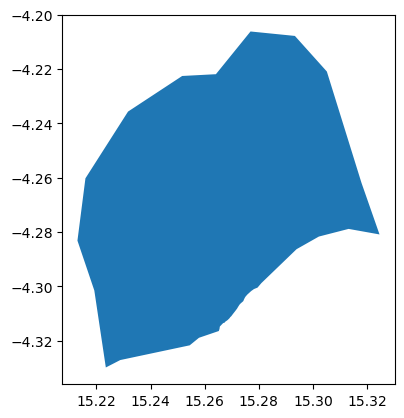

In [19]:
# This is the GeoPandas dataframe
display(city)
city.plot()

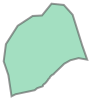

In [20]:
# This is the Shapely geometry object contained in the geodf
city_shp = city.geometry[0]
city_shp

We check to see everything lines up by running intersect and counting the True / False returns. The count of the True values are the number of roads that intersect the AOI \
**intersects** is a Shapely function that returns True if the boundary or interior of the object intersect in any way with those of the other


In [21]:
roads_osm.roads_raw.to_crs(epsg)
print(roads_osm.roads_raw.crs)
print(city.crs)

+init=epsg:4326 +type=crs
EPSG:4326


In [22]:
roads_osm.roads_raw.geometry.intersects(city_shp).value_counts()

False    48701
True      5986
Name: count, dtype: int64

We can therefore remove any roads that does not intersect Brazzaville administrative unit

In [23]:
roads_osm.roads_raw = roads_osm.roads_raw.loc[roads_osm.roads_raw.geometry.intersects(city_shp) == True]

Now we generate the RoadsGPD object, which is stored as a property of the 'OSM_to_network' object. The RoadsGPD object is a GeoDataFrame that further processes the roads.\
This includes splitting the edges where intersections occur, adding unique edge IDs, and adding to/from columns to the GeoDataFrame.\
We can do this using the **generateRoadsGDF** function

In [24]:
roads_osm.generateRoadsGDF(verbose = False)

We use the **initialReadIn()** function to transform this to a graph object

In [25]:
roads_osm.initialReadIn()

In [26]:
roads_osm.network

We save this graph object down to file using **gn.save()**. \
The save function produces three outputs: a node GeoDataFrame as a CSV, an edge GeoDataFrame as a CSV, and a graph object saved as a pickle (check your folder!).

In [27]:
gn.save(roads_osm.network,'roads_brazzaville',out_path)

### Import Friction Surface (.tif) 

In [241]:
travel_surf = rio.open(join(data_dir, f"travel_surface_motorized_2020_{iso}.tif"))
travel_surf.res

(0.008333333333333333, 0.008333333333333333)

### Import the Health Facilities (destinations)

Health facilities are stored as Geopandas dataframe

In [40]:
hf = gpd.read_file((data_dir+"/hf_COG.shp"))

In [41]:
hf = hf[hf.geometry.intersects(city_shp)]

In [42]:
display('The following categories and numbers of Health Facilities are considered to perform the analysis: ')
display(hf["Facility t"].value_counts())

'The following categories and numbers of Health Facilities are considered to perform the analysis: '

Facility t
Centre de Santé Intégré    22
l?Hôpital de Base           2
University Hospital         1
Name: count, dtype: int64

### Import Population (origin)

In [134]:
# wp_path = join(expanduser("R:/"), 'Data', 'GLOBAL/Population/WorldPop_PPP_2020/MOSAIC_ppp_prj_2020', f'ppp_prj_2020_{iso}.tif') # Download from link above
wp_path = join(data_dir, f'cog_ppp_2020_1km_Aggregated.tif') # Download from link above
pop_surf = rio.open(wp_path)

In [135]:
rMisc.clipRaster(pop_surf, city, join(data_dir, f"pop_brazaville.tif"), crop=True)

In [136]:
wp_path = join(data_dir, f'pop_brazaville.tif')
pop_surf = rio.open(wp_path)

In [187]:
# Create a population df from population surface 
indices = list(np.ndindex(pop_surf.shape))
xys = [Point(pop_surf.xy(ind[0], ind[1])) for ind in indices]
res_df = pd.DataFrame({
    'spatial_index': indices,
    'geometry': xys,
    'pop': pop_surf.read(1).flatten()
})
res_df = res_df[res_df["pop"] != -99999.0]
res_df.head(2)

,spatial_index,geometry,pop
8,"(0, 8)",POINT (15.277916606793564 -4.204583108029534),7612.103027
9,"(0, 9)",POINT (15.286249940093564 -4.204583108029534),8549.582031


Let's plot the location of the Health facilities, together with the travel surface dataset and the roads

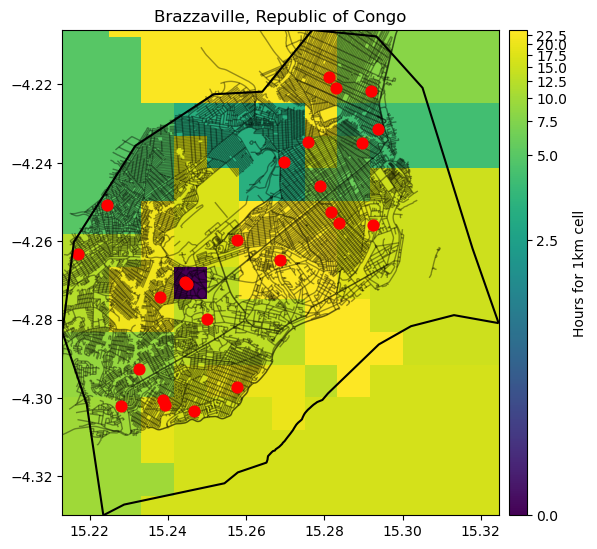

In [247]:
fig, ax = plt.subplots(figsize=(6, 8))
ax.set_title("Brazzaville, Republic of Congo", fontsize=12, horizontalalignment='center')

# Plot the flood data
pop_image = show(marketsheds, transform=travel_surf.transform, ax=ax, norm=colors.PowerNorm(gamma=0.15), cmap='viridis', alpha = 1, zorder = 2)
# travel_surf.read(1)*1000/60
# Create an axis divider for the colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size="4%", pad=0.1)

# Add the colorbar
cb = fig.colorbar(pop_image.get_images()[0], cax=cax, orientation='vertical')
cb.set_label("Hours for 1km cell")

# Plot the road network not impcted
roads_osm.roads_raw.plot(ax=ax, color='black', linewidth=1, alpha = 0.4, zorder = 2)
# PLot the Health facilities
hf.plot(ax=ax, color='red', markersize = 60, zorder=3)
city.boundary.plot(ax=ax, color = "black", zorder=3, edgecolor="black")

ax.set_xlim(city_shp.bounds[0], city_shp.bounds[2])
ax.set_ylim(city_shp.bounds[1], city_shp.bounds[3])

plt.show()

## Calculate Travel Time

In [81]:
with open(os.path.join(out_path, 'roads_brazzaville.gpickle'), 'rb') as f:
    G = pickle.load(f)

In [82]:
print('start: %s\n' % time.ctime())
G_clean = gn.clean_network(G, wpath = out_path, output_file_name = 'roads_brazzaville_clean', UTM = epsg_utm, WGS = epsg, junctdist = 10, verbose = True)

# using verbose = True:
# G_clean = gn.clean_network(G, wpath = data_pth, output_file_name = 'iceland_network', UTM = Iceland_UTMZ, WGS = {'init': 'epsg:4326'}, junctdist = 10, verbose = True)
print('\nend: %s' % time.ctime())
print('\n--- processing complete')

start: Thu Sep 12 10:56:30 2024

21554
completed processing 43108 edges
20985
completed processing 41970 edges
Edge reduction: 21554 to 41970 (-94 percent)

end: Thu Sep 12 10:56:57 2024

--- processing complete


Each edge in the network has a property called 'length'. This was actually computed during Step 1 when the generateRoadsGDF function was run. The units of this length are in kilometres.\
We can convert length to time, so that to calculate how long it takes to reach a destination, using the **convert_network_to_time** function.\
We use a factor of 1000, because the function is expecting meters, so we need to convert the units of kilometers to meters.   

Th**e convert_network_to_ti**me function uses a default speed dictionary that assigns speed limits to OSM highway types. However, it is possible to specify your own speed dictionary.

In [90]:
G_time = gn.convert_network_to_time(G_clean, distance_tag = 'length', road_col = 'infra_type', factor = 1000)

In [91]:
gn.example_edge(G_time)

(0, 1325, {'Wkt': 'LINESTRING (15.2475657 -4.2920382, 15.2467013 -4.2919278)', 'id': 2406, 'infra_type': 'residential', 'one_way': False, 'osm_id': '48569609', 'key': 'edge_2406', 'length': 96.72998683022037, 'Type': 'legitimate', 'time': 17.411397629439666, 'mode': 'drive'})


In order to perform network analysis we want to know the closest network node to each hospital.\
For this, we use the **pandana_snap_c** function to snap (project and retrive closest node distance) the hospitals locations to the road network:

In [184]:
gn.pandana_snap_c?

Signature:
gn.pandana_snap_c(
    G,
    point_gdf,
    source_crs='epsg:4326',
    target_crs='epsg:4326',
    add_dist_to_node_col=True,
    time_it=False,
)
Docstring:
snaps points to a graph at a faster speed than pandana_snap.
:param G: a graph object, or the node geodataframe of a graph
:param point_gdf: a geodataframe of points, in the same source crs as the geometry of the graph object
:param source_crs: The crs for the input G and input point_gdf in format 'epsg:32638' 
:param target_crs: The measure crs how distances between points are calculated. The returned point GeoDataFrame's CRS does not get modified. The crs object in format 'epsg:32638'
:param add_dist_to_node_col: return distance to nearest node in the units of the target_crs
:param time_it: return time to complete function
:return: returns a GeoDataFrame that is the same as the input point_gdf but adds a column containing the id of the nearest node in the graph, and the distance if add_dist_to_node_col == True
File:

In [165]:
destinations = gn.pandana_snap_c(G_time, hf, source_crs = epsg, target_crs = epsg_utm)
destinations.head(2)

,Country,Admin1,Facility n,Facility t,Ownership,Lat,Long,LL source,geometry,NN,NN_dist
23,Congo,Brazzaville,3 Martyrs Centre de Santé Intégré,Centre de Santé Intégré,MoH,-4.2704,15.2443,Combination,POINT (15.24430 -4.27040),3167,45.510237
24,Congo,Brazzaville,Bissita Centre de Santé Intégré,Centre de Santé Intégré,MoH,-4.3005,15.2387,Google Earth,POINT (15.23870 -4.30050),12530,58.768015


When calculating an OD-Matrix, we can only use the node IDs as inputs. So, we convert this column of our dataframe over to a list of unique values:

In [179]:
destinations = list(set(destinations.NN))

Now let's do the same for the origins

In [167]:
# Either use one single location, or a grid of locations, with a point for each cell of the population raster 
loc = [Point(15.25, -4.24)]
loc_gdf = gpd.GeoDataFrame({'geometry':loc}, crs = {'init':'epsg:4326'}, geometry = 'geometry', index = [1])

In [189]:
origins_gdf = gpd.GeoDataFrame(res_df["geometry"], crs = epsg)

In [236]:
origins = gn.pandana_snap_c(G_time, origins_gdf, source_crs = epsg, target_crs = epsg_utm)
origins = [row.NN for idx,row in origins.iterrows()]

The Origin Destination matrix displays the time (in seconds) to reach the 

In [238]:
OD = gn.calculate_OD(G_time, origins, destinations, fail_value = 9999999)

In [239]:
OD

array([[ 455.97075428,  384.80586467, 1584.46735752, ...,  750.99850665,
        1479.42870708,  918.54000375],
       [ 388.31285346,  302.93721397, 1659.05756661, ...,  762.84540117,
        1531.00604159,  993.13021284],
       [ 389.03973363,  436.96887641, 1669.84314267, ...,  678.33503068,
        1446.49567111,  991.77735525],
       ...,
       [1416.83559064, 1426.14071933, 1066.60141953, ..., 1034.53824266,
         272.93524563,  840.09558931],
       [1533.02969961, 1542.3348283 , 1182.7955285 , ..., 1150.73235163,
         389.1293546 ,  956.28969828],
       [1533.02969961, 1542.3348283 , 1182.7955285 , ..., 1150.73235163,
         389.1293546 ,  956.28969828]])

In [240]:
OD = OD / 60
OD_df = pd.DataFrame(OD, columns = destinations, index = origins)
OD_df

,7682,6020,900,7943,8072,9232,1692,3877,12841,2349,...,3395,7112,3149,12123,3167,10595,8676,5101,12530,2806
4019,7.599513,6.413431,26.407789,10.780243,8.448830,19.711251,14.084332,23.769943,19.220016,26.969619,...,20.444827,8.121287,25.594944,10.199661,19.642977,11.741221,23.444175,12.516642,24.657145,15.309000
687,6.471881,5.048954,27.650959,12.023413,9.692000,20.601789,13.958396,24.629566,19.638232,27.829241,...,21.687997,6.146792,26.454566,8.317245,20.886147,10.393093,24.687345,12.714090,25.516767,16.552170
5402,6.483996,7.282815,27.830719,12.203172,9.871760,19.193283,12.549890,23.221060,18.229726,26.420735,...,21.437101,4.738286,25.046060,6.908738,20.084285,8.984587,24.867105,11.305584,24.108261,16.529623
2685,3.311977,3.346300,22.120253,6.492707,4.161294,15.423714,9.796796,19.482407,14.932480,22.682083,...,16.157291,5.240373,21.307408,5.912125,15.355441,7.453685,19.156639,8.229106,20.369609,11.021464
13068,4.446298,2.827633,24.002227,8.374680,6.043268,17.305688,11.678770,21.364381,16.814454,24.564056,...,18.039265,6.273995,23.189382,7.163018,17.237414,8.957292,21.038612,10.111080,22.251583,12.903438
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1362,25.550495,25.705580,19.713259,19.408478,20.747305,10.756471,19.343176,11.315606,16.233197,8.501634,...,12.104287,24.880330,4.478690,23.181197,14.112743,23.230521,22.206405,19.178873,6.485489,15.938162
8608,22.844689,22.999774,17.007453,16.702672,18.041499,8.050665,16.637370,8.609800,13.527391,5.795828,...,9.398481,22.174524,1.772884,20.475392,11.406937,20.524715,19.500599,16.473067,3.779683,13.232356
9713,23.613927,23.769012,17.776690,17.471909,18.810737,8.819903,17.406607,9.379037,14.296629,6.565065,...,10.167719,22.943761,2.542122,21.244629,12.176175,21.293952,20.269836,17.242304,4.548921,14.001593
1362,25.550495,25.705580,19.713259,19.408478,20.747305,10.756471,19.343176,11.315606,16.233197,8.501634,...,12.104287,24.880330,4.478690,23.181197,14.112743,23.230521,22.206405,19.178873,6.485489,15.938162


Testing the marketsheds

In [243]:
ma.generate_market_sheds(travel_surf, hf, out_file = os.path.join(out_path, 'marketsheds_test.tif'))

In [246]:
marketsheds = rio.open(os.path.join(out_path, 'marketsheds_test.tif'))
marketsheds.plot()

AttributeError: 'DatasetReader' object has no attribute 'plot'